# Server Utilization Clustering (Improved)
Exploratory Data Analysis and robust K-Means clustering for server utilization data.
This notebook adds safer preprocessing, richer features, multiple cluster-quality metrics, clearer visualizations, and attaches cluster labels back to the raw data for downstream analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Use seaborn's style via seaborn API (matplotlib may not have seaborn-whitegrid style available in some environments)
sns.set_style("whitegrid")
sns.set_context("talk")


In [2]:
# --- Load data ---
df = pd.read_csv("historical_server_data.csv", parse_dates=["date"])  # expects file in same folder
# Basic quick view
print("Rows:", len(df))
print("Unique servers:", df["server"].nunique())
print(df.dtypes)
print(df.isna().sum())

# --- Robust preprocessing: coerce numeric types and normalize power_state to numeric ---
num_cols = ["cpu_avg", "cpu_max", "mem_avg", "mem_max"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Normalize power_state to a numeric 0/1 column (power_state_numeric). Handles common string encodings.
if "power_state" in df.columns:
    # Try mapping common string values to 0/1
    mapping = {
        "on": 1, "off": 0,
        "running": 1, "stopped": 0,
        "up": 1, "down": 0,
        "true": 1, "false": 0,
        True: 1, False: 0,
        "True": 1, "False": 0,
        "1": 1, "0": 0,
        1: 1, 0: 0
    }
    # Map strings (case-insensitive) where applicable
    def map_power(val):
        if pd.isna(val):
            return np.nan
        try:
            return mapping[val]
        except Exception:
            # try lowercased string
            try:
                sval = str(val).strip().lower()
                return mapping.get(sval, np.nan)
            except Exception:
                return np.nan

    df["power_state_numeric"] = df["power_state"].apply(map_power)
    # If mapping produced all NaN or mostly NaN, try coercing directly to numeric
    if df["power_state_numeric"].isna().sum() > 0.5 * len(df):
        df["power_state_numeric"] = pd.to_numeric(df["power_state"], errors="coerce")
    # Fill remaining NaNs conservatively with 0 (assume off) to allow aggregation; user can change this strategy
    df["power_state_numeric"] = df["power_state_numeric"].fillna(0).astype(int)
else:
    # If missing, create a column of zeros (all off) to keep pipeline consistent
    df["power_state_numeric"] = 0


Rows: 17819
Unique servers: 103
date           datetime64[ns]
server                 object
power_state             int64
cpu_avg               float64
cpu_max               float64
mem_avg               float64
mem_max               float64
dtype: object
date           0
server         0
power_state    0
cpu_avg        0
cpu_max        0
mem_avg        0
mem_max        0
dtype: int64


## Exploratory plots (quick)

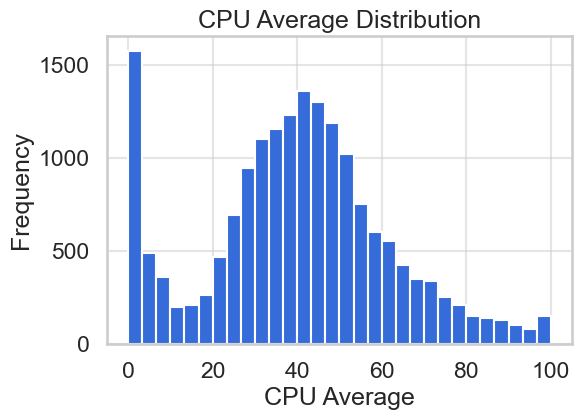

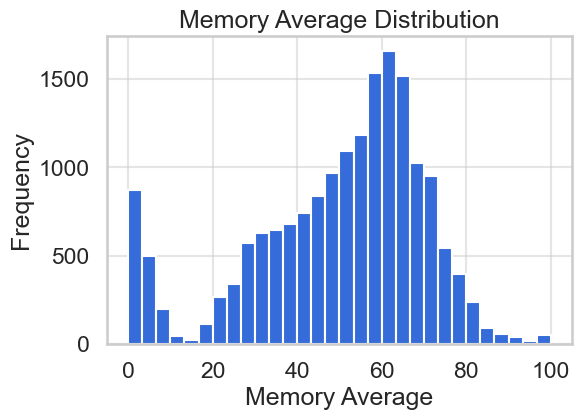

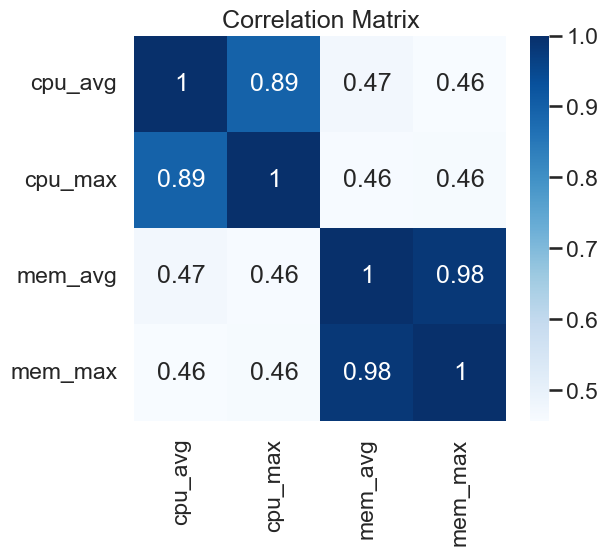

In [3]:
plt.figure(figsize=(6,4))
plt.hist(df["cpu_avg"].dropna(), bins=30)
plt.xlabel("CPU Average")
plt.ylabel("Frequency")
plt.title("CPU Average Distribution")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["mem_avg"].dropna(), bins=30)
plt.xlabel("Memory Average")
plt.ylabel("Frequency")
plt.title("Memory Average Distribution")
plt.show()

# Correlation
corr = df[["cpu_avg","cpu_max","mem_avg","mem_max"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()


## Server-level feature engineering

/var/folders/3n/d3zngy3s6cb6n2xjvwnqg2vr0000gp/T/ipykernel_44885/2130944.py:46: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

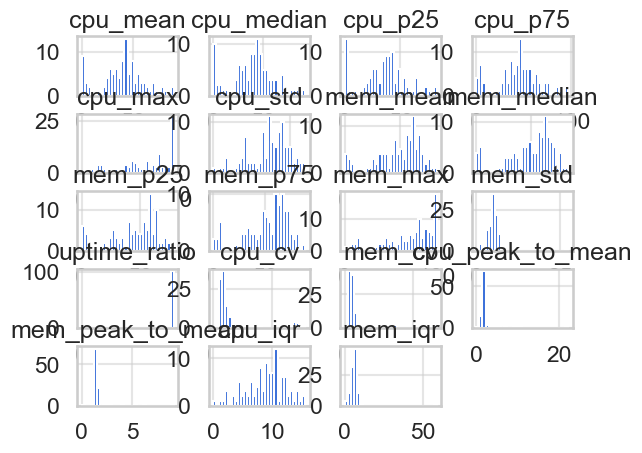

In [4]:
# Aggregations with percentiles and counts (explicit, robust to object dtypes)
# Ensure numeric columns are numeric before aggregation
for c in ["cpu_avg", "cpu_max", "mem_avg", "mem_max"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

grp = df.groupby("server")
agg = pd.DataFrame({
    "server": grp.size().index,
    "cpu_mean": grp["cpu_avg"].mean(),
    "cpu_median": grp["cpu_avg"].median(),
    "cpu_p25": grp["cpu_avg"].apply(lambda x: np.percentile(x.dropna(), 25) if x.dropna().size>0 else np.nan),
    "cpu_p75": grp["cpu_avg"].apply(lambda x: np.percentile(x.dropna(), 75) if x.dropna().size>0 else np.nan),
    "cpu_max": grp["cpu_max"].max(),
    "cpu_std": grp["cpu_avg"].std(),
    "mem_mean": grp["mem_avg"].mean(),
    "mem_median": grp["mem_avg"].median(),
    "mem_p25": grp["mem_avg"].apply(lambda x: np.percentile(x.dropna(), 25) if x.dropna().size>0 else np.nan),
    "mem_p75": grp["mem_avg"].apply(lambda x: np.percentile(x.dropna(), 75) if x.dropna().size>0 else np.nan),
    "mem_max": grp["mem_max"].max(),
    "mem_std": grp["mem_avg"].std(),
    "uptime_ratio": grp["power_state_numeric"].mean(),
    "samples_count": grp["cpu_avg"].count()
}).reset_index(drop=True)

# Derived features
agg["cpu_cv"] = agg["cpu_std"] / agg["cpu_mean"].replace(0, np.nan)
agg["mem_cv"] = agg["mem_std"] / agg["mem_mean"].replace(0, np.nan)
agg["cpu_peak_to_mean"] = agg["cpu_max"] / agg["cpu_mean"].replace(0, np.nan)
agg["mem_peak_to_mean"] = agg["mem_max"] / agg["mem_mean"].replace(0, np.nan)
agg["cpu_iqr"] = agg["cpu_p75"] - agg["cpu_p25"]
agg["mem_iqr"] = agg["mem_p75"] - agg["mem_p25"]

# Handle NaNs produced by single-sample std or zero means
fill_zero_cols = ["cpu_std","mem_std","cpu_cv","mem_cv","cpu_peak_to_mean","mem_peak_to_mean"]
for col in fill_zero_cols:
    if col in agg.columns:
        agg[col] = agg[col].fillna(0)

# Optionally drop server name and sample counts for clustering
features = agg.drop(columns=["server","samples_count"]).set_index(agg["server"])  # keep index as server for clarity

# Quick diagnostics
plt.figure(figsize=(12,8))
features.hist(bins=30)
plt.tight_layout()
plt.show()


## Scaling and transformation

In [5]:
# Use PowerTransformer to reduce skew, fall back to RobustScaler if transform fails
X = features.copy()
try:
    pt = PowerTransformer(method="yeo-johnson")
    X_trans = pd.DataFrame(pt.fit_transform(X), columns=X.columns, index=X.index)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_trans)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
    print("Applied PowerTransformer + StandardScaler")
except Exception as e:
    print("PowerTransformer failed, using RobustScaler:", e)
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)


Applied PowerTransformer + StandardScaler


## Select K using multiple metrics

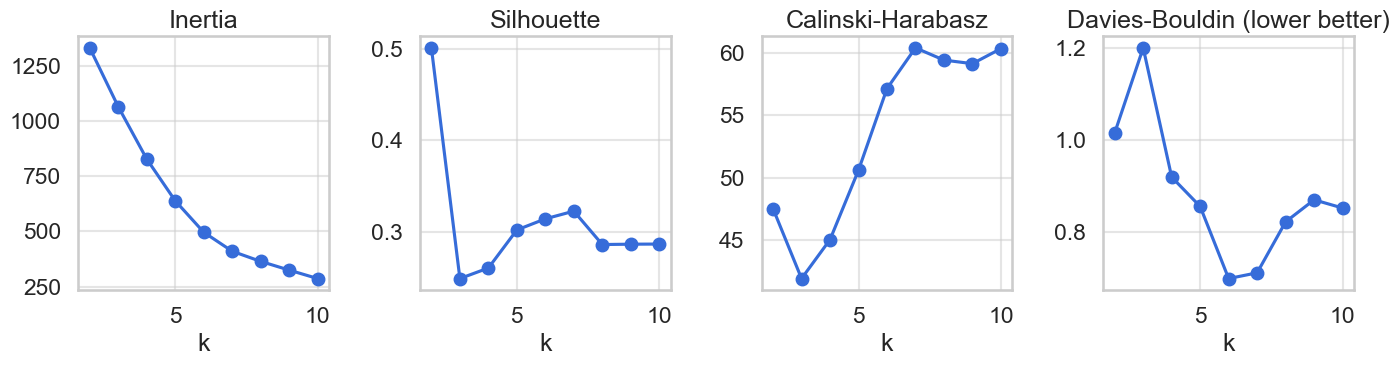

Best k by silhouette: 2


In [6]:
k_range = range(2, 11)
inertia = []
sil_scores = []
ch_scores = []
db_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

plt.figure(figsize=(14,4))
plt.subplot(1,4,1)
plt.plot(list(k_range), inertia, '-o')
plt.title('Inertia')
plt.xlabel('k')

plt.subplot(1,4,2)
plt.plot(list(k_range), sil_scores, '-o')
plt.title('Silhouette')
plt.xlabel('k')

plt.subplot(1,4,3)
plt.plot(list(k_range), ch_scores, '-o')
plt.title('Calinski-Harabasz')
plt.xlabel('k')

plt.subplot(1,4,4)
plt.plot(list(k_range), db_scores, '-o')
plt.title('Davies-Bouldin (lower better)')
plt.xlabel('k')

plt.tight_layout()
plt.show()

# Choose a k (example: highest silhouette)
best_k = list(k_range)[int(np.argmax(sil_scores))]
print("Best k by silhouette:", best_k)


## Final KMeans model and stability

In [7]:
final_k = 6
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=50)
labels = kmeans.fit_predict(X_scaled)
agg["cluster"] = labels
X_scaled_df["cluster"] = labels

# Cluster sizes
print(agg.groupby('cluster').size())


cluster
0    33
1    31
2     8
3     1
4    29
5     1
dtype: int64


## PCA visualization with centroids

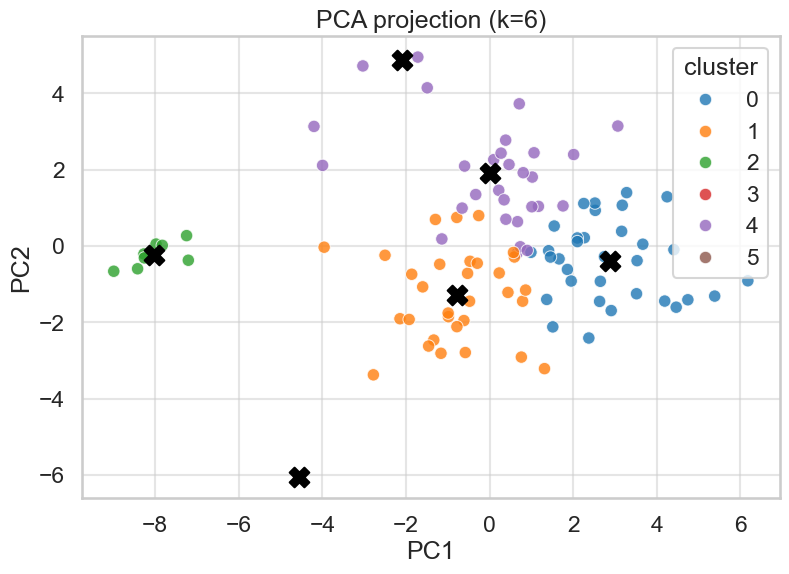

In [8]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame(pcs, columns=["PC1","PC2"], index=X_scaled_df.index)
plot_df['cluster'] = labels

plt.figure(figsize=(9,6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster', palette='tab10', s=80, alpha=0.8)
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], marker='X', s=200, c='black', label='centroids')
plt.title(f'PCA projection (k={final_k})')
plt.show()


## Silhouette plot (per-sample)

/var/folders/3n/d3zngy3s6cb6n2xjvwnqg2vr0000gp/T/ipykernel_44885/4272395252.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = cm.get_cmap('nipy_spectral')(float(i) / final_k)


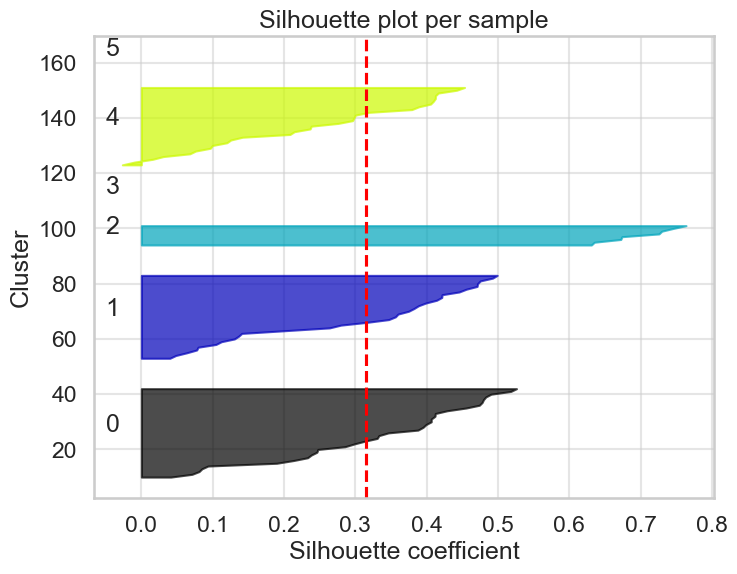

In [9]:
from matplotlib import cm
sample_sil_values = silhouette_samples(X_scaled, labels)
y_lower = 10
plt.figure(figsize=(8,6))
for i in range(final_k):
    ith_sil_vals = sample_sil_values[labels == i]
    ith_sil_vals.sort()
    size_cluster_i = ith_sil_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    # use get_cmap for compatibility across matplotlib versions
    color = cm.get_cmap('nipy_spectral')(float(i) / final_k)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil_vals, facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10
plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.title("Silhouette plot per sample")
plt.axvline(x=silhouette_score(X_scaled, labels), color="red", linestyle="--")
plt.show()


## Cluster profiling


agg dtypes before coercion:
server               object
cpu_mean            float64
cpu_median          float64
cpu_p25             float64
cpu_p75             float64
cpu_max             float64
cpu_std             float64
mem_mean            float64
mem_median          float64
mem_p25             float64
mem_p75             float64
mem_max             float64
mem_std             float64
uptime_ratio        float64
samples_count         int64
cpu_cv              float64
mem_cv              float64
cpu_peak_to_mean    float64
mem_peak_to_mean    float64
cpu_iqr             float64
mem_iqr             float64
cluster               int32
dtype: object


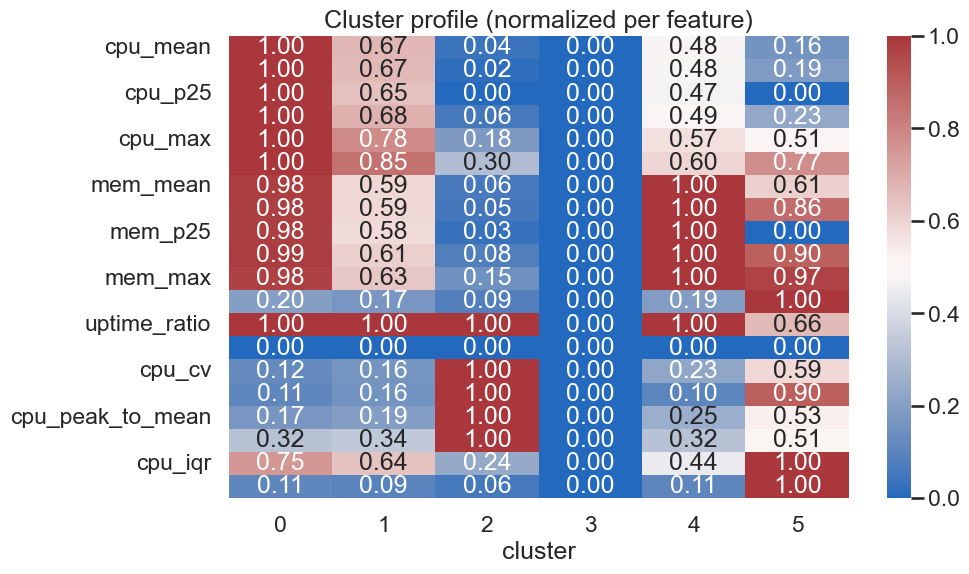


Cluster 0: size=33
                     server  cpu_mean  cpu_max  mem_mean  uptime_ratio
 gti-com-hp27.hci.bri.co.id 89.668497   100.00 76.719075           1.0
 gti-com-hp25.hci.bri.co.id 86.916012   100.00 70.607861           1.0
 gti-com-hp40.hci.bri.co.id 83.090636   100.00 63.688150           1.0
 gti-com-hp38.hci.bri.co.id 80.115723   100.00 62.661214           1.0
 gti-com-hp39.hci.bri.co.id 78.837399   100.00 59.016243           1.0
 gti-com-hp42.hci.bri.co.id 72.066590   100.00 61.496879           1.0
 gti-com-hp09.hci.bri.co.id 69.989827    99.33 47.877052           1.0
gti-com-lnv22.hci.bri.co.id 69.843353   100.00 69.563295           1.0
gti-com-lnv29.hci.bri.co.id 68.971329   100.00 57.972543           1.0
 gti-com-hp47.hci.bri.co.id 67.846590   100.00 55.038497           1.0

Cluster 1: size=31
                     server  cpu_mean  cpu_max  mem_mean  uptime_ratio
gti-com-mdm01.hci.bri.co.id 64.823873   100.00 31.500578           1.0
 gti-com-hp02.hci.bri.co.id 59.577168

In [10]:
# Diagnostics + Cluster profile: coerce numeric-like columns and work only with numeric columns
print('\nagg dtypes before coercion:')
print(agg.dtypes)

# Attempt to coerce any numeric-like columns to numeric to avoid groupby mean errors
for col in agg.columns:
    if col in ['server', 'cluster']:
        continue
    if not pd.api.types.is_numeric_dtype(agg[col]):
        # coerce and report how many values became NaN
        coerced = pd.Series(pd.to_numeric(agg[col], errors='coerce'), index=agg.index)
        n_coerced = int(coerced.isna().sum())
        if n_coerced > 0:
            print(f"Coerced column '{col}' to numeric with {n_coerced} NaNs")
        agg[col] = coerced

# Ensure cluster is numeric
if not pd.api.types.is_numeric_dtype(agg['cluster']):
    temp_cluster = pd.Series(pd.to_numeric(agg['cluster'], errors='coerce'), index=agg.index)
    agg['cluster'] = temp_cluster.fillna(-1).astype(int)

numeric_cols = agg.select_dtypes(include=[np.number]).columns.tolist()
if 'cluster' in numeric_cols:
    numeric_cols.remove('cluster')

if len(numeric_cols) == 0:
    print("No numeric features available for cluster profiling.")
else:
    profile = agg.groupby('cluster')[numeric_cols].mean().T
    # normalize per row to make heatmap readable
    denom = (profile.max(axis=1) - profile.min(axis=1)).replace(0, 1e-9)
    profile_scaled = (profile.subtract(profile.min(axis=1), axis=0)).divide(denom, axis=0)
    plt.figure(figsize=(10,6))
    sns.heatmap(profile_scaled, annot=True, fmt='.2f', cmap='vlag')
    plt.title('Cluster profile (normalized per feature)')
    plt.show()

# Print top servers per cluster by cpu_mean (guard if cpu_mean missing)
for c in sorted(agg['cluster'].unique()):
    print(f"\nCluster {c}: size={len(agg[agg['cluster']==c])}")
    subset_df = agg[agg['cluster']==c]
    if len(subset_df) > 0:
        if 'cpu_mean' in subset_df.columns:
            idx = np.argsort(-subset_df['cpu_mean'].values)[:10]
            subset = subset_df.iloc[idx][[col for col in ['server','cpu_mean','cpu_max','mem_mean','uptime_ratio'] if col in subset_df.columns]]
            print(subset.to_string(index=False))
        else:
            # Fallback: show first 10 rows with available columns
            cols = ['server'] + [c for c in subset_df.columns if c != 'server']
            print(subset_df[cols].head(10).to_string(index=False))
    else:
        print(f"No servers in cluster {c}")


## Attach cluster labels back to raw timeseries

/var/folders/3n/d3zngy3s6cb6n2xjvwnqg2vr0000gp/T/ipykernel_44885/1891261808.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df_labeled.groupby([df_labeled['date'].dt.floor('H'), 'cluster'])['cpu_avg'].mean().unstack()


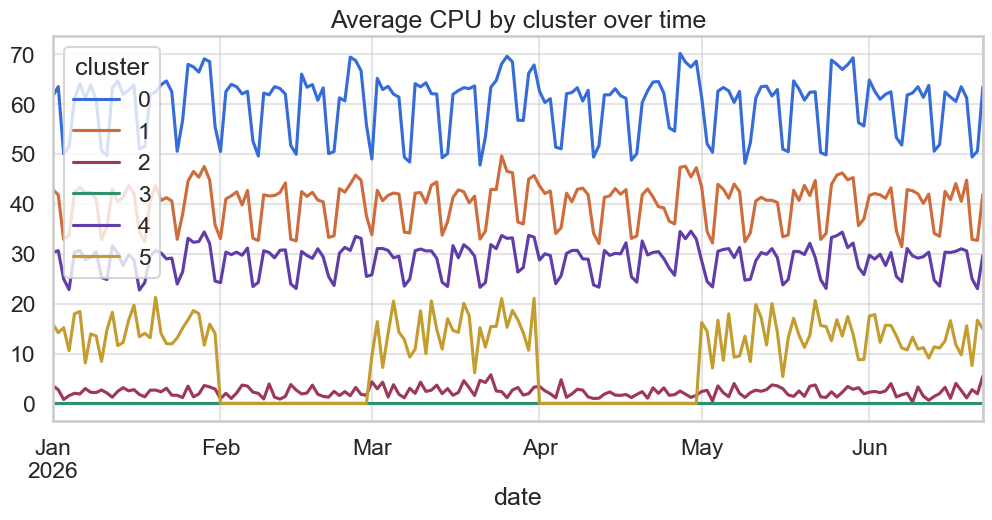

In [11]:
df_labeled = df.merge(agg[["server","cluster"]], on="server", how="left")

# Example: average CPU over time per cluster
ts = df_labeled.groupby([df_labeled['date'].dt.floor('H'), 'cluster'])['cpu_avg'].mean().unstack()
ts.plot(figsize=(12,5), title='Average CPU by cluster over time')
plt.show()


## Save results (optional)

In [12]:
agg.to_csv('server_cluster_profiles.csv', index=False)
df_labeled.to_csv('historical_server_data_labeled.csv', index=False)


## Next steps
- Validate clusters by inspecting servers in each group (make sure they match expected production/test/standby roles).
- If clusters are poorly separated or highly imbalanced consider GaussianMixture or HDBSCAN.
- Add temporal features (peak-hour usage, fraction > threshold) if you need finer behavioral clusters.
- Run clustering stability tests by fitting with multiple random seeds and comparing assignments (adjusted rand index).

print('Done — improved clustering notebook updated.')
